In [22]:
from dataset_preprocessing.ADC.compute_ADC import compute_adc_multi_bvec
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import os
from tqdm import tqdm

In [5]:
#ROOT_DIR = "/home/fehrdelt/bettik/"
ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"

In [6]:
ixi_folder = f"{ROOT_DIR}/datasets/IXI-DTI/"

In [8]:
# Find first NIfTI file and print its shape
nii_files = [f for f in os.listdir(ixi_folder) if f.lower().endswith(('.nii', '.nii.gz'))]

patient_ids = set(f.split('-')[2] for f in nii_files)


In [27]:
for patient_id in tqdm(list(patient_ids)):
    #
    b0_file = [f for f in nii_files if f"-{patient_id}-DTI-00" in f]
    #print(b0_file)
    if len(b0_file) != 0 and not os.path.exists(os.path.join(f'{ROOT_DIR}/datasets/IXI_ADC/', f"{patient_id}_adc.nii.gz")):
        b0_nifti = nib.load(os.path.join(ixi_folder, b0_file[0]))
        b0_data = b0_nifti.get_fdata()

        b1000_files = [f for f in nii_files if f"-{patient_id}-DTI" in f and not f"DTI-00" in f]
        try:
            b1000_stacked = np.stack([nib.load(os.path.join(ixi_folder, f)).get_fdata() for f in sorted(b1000_files)], axis=-1)
        except Exception as e:
            print(f"Error stacking b1000 images for patient {patient_id}: {e}")
            continue

        adc_map = compute_adc_multi_bvec(b0_data, b1000_stacked, 1000)
        adc_map = np.clip(adc_map, 0, 4)*1000

        adc_nifti = nib.Nifti1Image(adc_map, b0_nifti.affine, b0_nifti.header)
        save_path = os.path.join(f'{ROOT_DIR}/datasets/IXI_ADC/', f"{patient_id}_adc.nii.gz")
        nib.save(adc_nifti, save_path)
        #print(f"Saved ADC map for patient {patient_id} to {save_path}")
    

 68%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                                                          | 273/400 [00:00<00:00, 907.95it/s]

Error stacking b1000 images for patient 1074: all input arrays must have the same shape


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 400/400 [00:58<00:00,  6.89it/s]


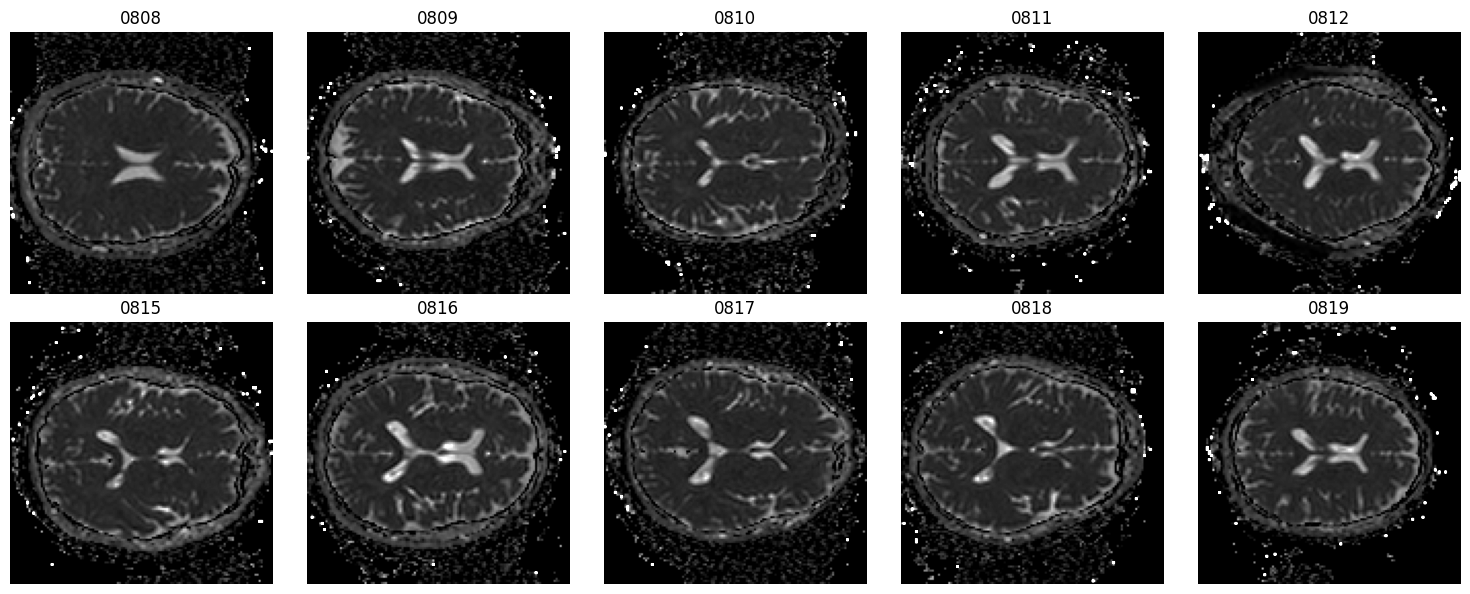

In [29]:
adc_dir = f"{ROOT_DIR}/datasets/IXI_ADC/"
adc_files = sorted([f for f in os.listdir(adc_dir) if f.endswith('.nii.gz')])[:10]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, fname in enumerate(adc_files):
    img = nib.load(os.path.join(adc_dir, fname))
    data = img.get_fdata()*1000
    mid_slice = data[:, :, data.shape[2] // 2]
    axes[i].imshow(mid_slice, cmap='gray', vmin=0, vmax=4000)
    axes[i].set_title(fname.split('_')[0])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

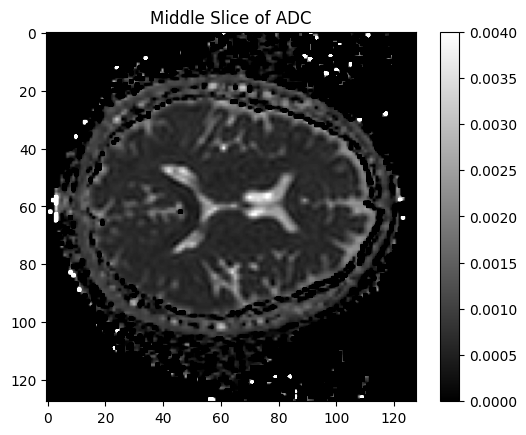

In [19]:
plt.imshow(adc_map[:, :, adc_map.shape[2] // 2], cmap='gray', vmin=0, vmax=0.004)
plt.colorbar()
plt.title('Middle Slice of ADC')
plt.show()